In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch

import tensorflow as tf
from tensorflow.keras import layers

/Users/adelaidegray1/Desktop/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
os.chdir("/Users/adelaidegray1/Desktop/PIC 16B")     
print(os.getcwd())   # it should be in the folder that you have the datasets folder in

/Users/adelaidegray1/Desktop/PIC 16B


In [3]:
train_tensors = []
val_tensors = []
test_tensors = []

scenes = ['eth', 'hotel', 'univ', 'zara1', 'zara2']

for scene in scenes:
    train_tensors.append(torch.load(f'datasets/{scene}/train.pt'))
    val_tensors.append(torch.load(f'datasets/{scene}/val.pt'))
    test_tensors.append(torch.load(f'datasets/{scene}/test.pt'))

train_data = torch.cat(train_tensors, dim=0)
val_data = torch.cat(val_tensors, dim=0)
test_data = torch.cat(test_tensors, dim=0)

In [4]:
# add velocity 
train_vel = train_data[:, 1:, :] - train_data[:, :-1, :]
val_vel = val_data[:, 1:, :] - val_data[:, :-1, :]
test_vel = test_data[:, 1:, :] - test_data[:, :-1, :]

zero_pad_train = torch.zeros(train_data.shape[0], 1, 2)
zero_pad_val = torch.zeros(val_data.shape[0], 1, 2)
zero_pad_test = torch.zeros(test_data.shape[0], 1, 2)

train_v = torch.cat([zero_pad_train, train_vel], dim=1)
val_v = torch.cat([zero_pad_val, val_vel], dim=1)
test_v = torch.cat([zero_pad_test, test_vel], dim=1)

train_data = torch.cat([train_data, train_v], dim=2)
val_data = torch.cat([val_data, val_v], dim=2)
test_data = torch.cat([test_data, test_v], dim=2)

# now the shape is ([N, 20, 4]) because the last dimension has (x, y, vx, vy)
print(train_data.shape)
print(val_data.shape)
print(test_data.shape)

torch.Size([124510, 20, 4])
torch.Size([22871, 20, 4])
torch.Size([34161, 20, 4])


In [5]:
X_train = train_data[:, :8, :]
Y_train = train_data[:, 8:, :-2]    # don't include velocities in Y data

X_val = val_data[:, :8, :]
Y_val = val_data[:, 8:, :-2]

X_test = test_data[:, :8, :]
Y_test = test_data[:, 8:, :-2]

In [6]:
model = tf.keras.models.Sequential([
    layers.LSTM(64, input_shape=(8,4)),
    layers.Dense(24),            # 24 because 12 future timesteps * 2 coordinate (x,y)
    layers.Reshape((12,2))
])

loss_fn = tf.keras.losses.MeanSquaredError()
model.compile(
    optimizer='adam',
    loss=loss_fn, 
    metrics = ['mae']
)

model.summary()

/Users/adelaidegray1/Desktop/.venv/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │         1,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 12, 2)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,224 (75.09 KB)

 Trainable params: 19,224 (75.09 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    epochs=20,       # number of times the model sees all of the data
    batch_size=64    # number of samples processed before updating weights
)

Epoch 1/20
1946/1946 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.5617 - mae: 0.4110 - val_loss: 0.3072 - val_mae: 0.3057
Epoch 2/20
1946/1946 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3215 - mae: 0.3197 - val_loss: 0.2878 - val_mae: 0.2980
Epoch 3/20
1946/1946 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3020 - mae: 0.3070 - val_loss: 0.2796 - val_mae: 0.2868
Epoch 4/20
1946/1946 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.2918 - mae: 0.2996 - val_loss: 0.2756 - val_mae: 0.2875
Epoch 5/20
1946/1946 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.2894 - mae: 0.2967 - val_loss: 0.2716 - val_mae: 0.2816
Epoch 6/20
1946/1946 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2835 - mae: 0.2935 - val_loss: 0.2800 - val_mae: 0.2905
Epoch 7/20
1946/1946 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.2770 - mae: 0.2904 - val_loss: 0.2653 - val_mae: 0.2800
Epoch 8/20
1946/1946 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.2779 - mae: 0.2911 - val_loss: 0.2655 - val_mae: 0.2789
Epoch 9/20
1946/1946 ━━━━━━━━━━━━━━━━━━━

In [8]:
test_loss = model.evaluate(X_test, Y_test)
print(test_loss)

1068/1068 ━━━━━━━━━━━━━━━━━━━━ 1s 859us/step - loss: 0.2427 - mae: 0.2808
[0.24064922332763672, 0.2766050696372986]


In [9]:
pred = model.predict(X_test)


1068/1068 ━━━━━━━━━━━━━━━━━━━━ 1s 779us/step


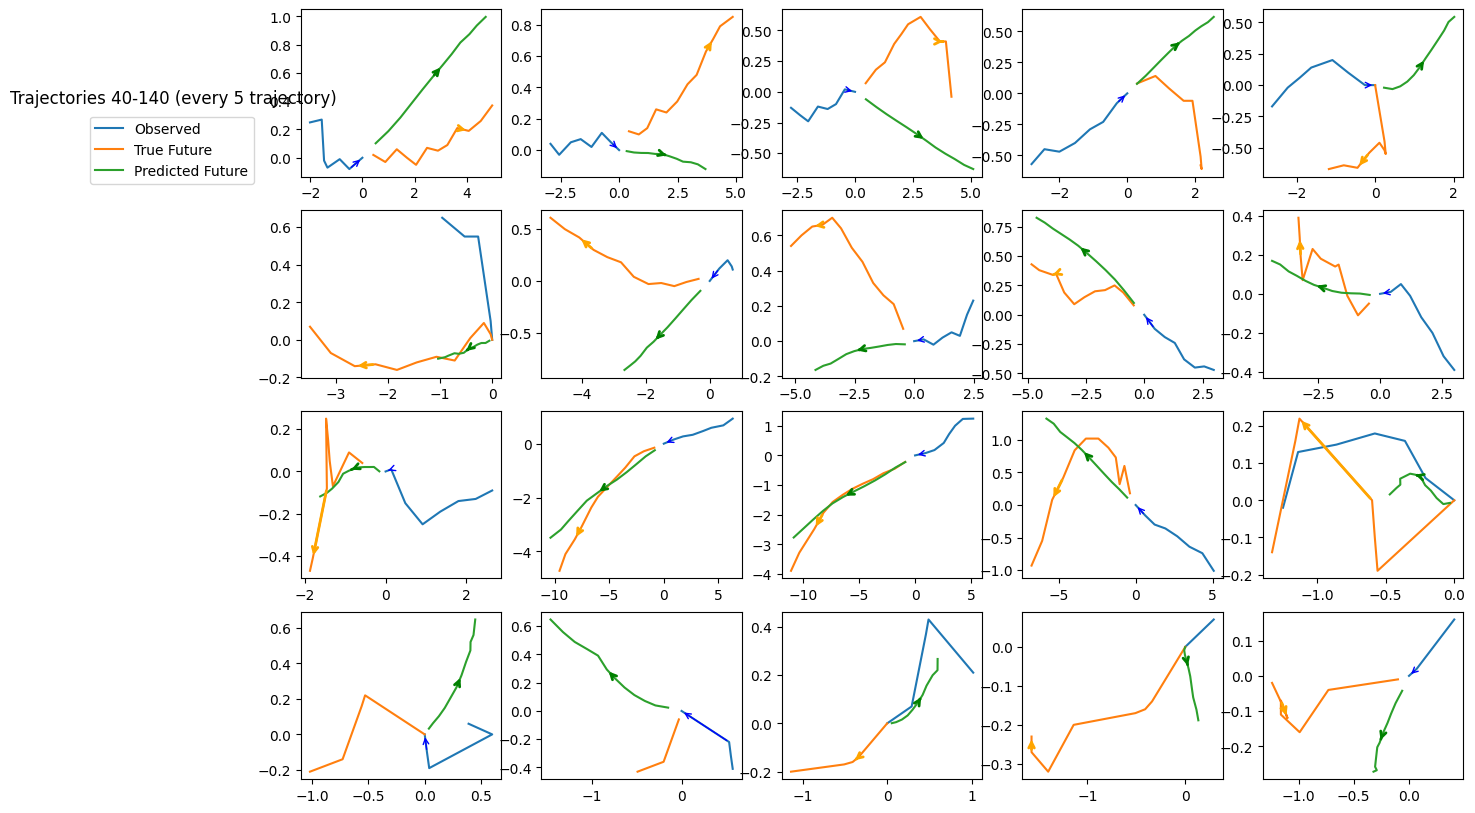

In [10]:
fig,ax = plt.subplots(4,5,figsize=(15,10))
ax=ax.flatten()

# start of trajectories to show
n_start = 40
n = n_start
for i in range(20):
    n += 5
    ax[i].plot(X_test[n,:,0], X_test[n,:,1], label='Observed')
    ax[i].plot(Y_test[n,:,0], Y_test[n,:,1], label='True Future')
    ax[i].plot(pred[n,:,0], pred[n,:,1], label='Predicted Future')

    # add arrows
    ax[i].annotate('', 
            xy=(pred[n,6,0], pred[n,6,1]), 
            xytext=(pred[n,5,0], pred[n,5,1]),
            arrowprops=dict(arrowstyle="->", color='green', lw=2))
    ax[i].annotate('', 
            xy=(Y_test[n,-3,0], Y_test[n,-3,1]), 
            xytext=(Y_test[n,-4,0], Y_test[n,-4,1]),
            arrowprops=dict(arrowstyle="->", color='orange', lw=2))
    ax[i].annotate('', 
            xy=(X_test[n,-1,0], X_test[n,-1,1]), 
            xytext=(X_test[n,-2,0], X_test[n,-2,1]),
            arrowprops=dict(arrowstyle="->", color='blue', lw=1))


plt.legend(bbox_to_anchor=(-5,4))
plt.suptitle(f'Trajectories {n_start}-{n} (every 5 trajectory)', x=.04, y=.8)
plt.show()

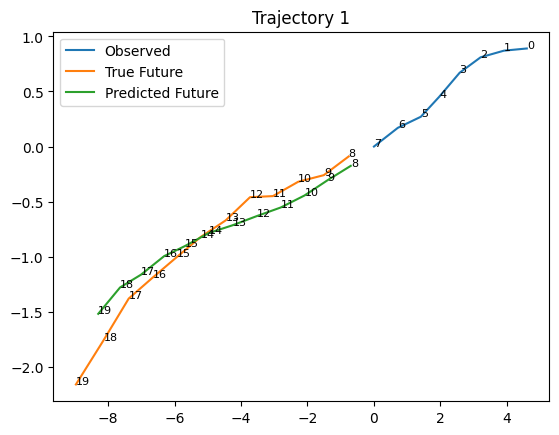

In [11]:
# close-up on one trajectory prediction
n=1
plt.plot(X_test[n,:,0], X_test[n,:,1], label='Observed')
plt.plot(Y_test[n,:,0], Y_test[n,:,1], label='True Future')
plt.plot(pred[n,:,0], pred[n,:,1], label='Predicted Future')

# add labels
for i in range(20):
    if i<8:
        plt.text(X_test[n,i,0], X_test[n,i,1], str(i), fontsize=8)
    else:
        plt.text(Y_test[n,i-8,0], Y_test[n,i-8,1], str(i), fontsize=8)
        plt.text(pred[n,i-8,0], pred[n,i-8,1], str(i), fontsize=8)

plt.legend()
plt.title(f'Trajectory {n}')
plt.show()